**xception71.tf_in1k para clasificación de texturas de llantas**

In [1]:
pip install grad-cam opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 115.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=cb587a03a8eb4ce7cd888359f6b320d41b072008564b6eeaeab13f895fa17ab0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import os
import copy
import random
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm

# Intenta importar Grad-CAM
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRAD_CAM_AVAILABLE = True
except ImportError:
    GRAD_CAM_AVAILABLE = False
    print("Grad-CAM no está disponible. Instale con: pip install grad-cam opencv-python")

In [3]:
# -----------------------------
# 1. Reproducibilidad Estricta (Fijar Semillas)
# -----------------------------
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [4]:
# -----------------------------
# 2. Configuración General y Switches
# -----------------------------
BATCH_SIZE = 8
LEARNING_RATE_FASE1 = 1e-4
LEARNING_RATE_FASE2 = 2e-5
EPOCHS_FASE1 = 30
EPOCHS_FASE2 = 30
PATIENCE = 9
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
XCEPTION_VARIANT = 'xception71.tf_in1k'

USE_CUSTOM_PREPROCESS = True
USE_AUGMENTATION = True

ZIP_PATH = '/content/drive/MyDrive/TireTextureImageRecognition.zip'
EXTRACT_PATH = '/content/dataset_tire'
TRAIN_DATA_DIR = os.path.join(EXTRACT_PATH, 'Tire Textures/training_data')
TEST_DATA_DIR = os.path.join(EXTRACT_PATH, 'Tire Textures/testing_data')

print(f"Dispositivo: {DEVICE} | Semilla: {SEED} | Preprocesamiento Custom: {USE_CUSTOM_PREPROCESS}")

Dispositivo: cuda | Semilla: 42 | Preprocesamiento Custom: True


In [5]:
# -----------------------------
# 3. Montar Google Drive y descomprimir datos
# -----------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive montado.")
except ImportError:
    print("No estamos en Colab, omitiendo montaje.")

if not os.path.exists(EXTRACT_PATH):
    if os.path.exists(ZIP_PATH):
        print(f"Descomprimiendo {ZIP_PATH} ...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)
    else:
        raise FileNotFoundError(f"No se encontró el archivo {ZIP_PATH}")

Mounted at /content/drive
Drive montado.
Descomprimiendo /content/drive/MyDrive/TireTextureImageRecognition.zip ...


In [6]:
# -----------------------------
# 4. Transformaciones Modulares
# -----------------------------
class HybridCLAHEBlackHat(object):
    def __init__(self, tile_grid=(8, 8), k_size=9, alpha=0.7, beta=0.3):
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=tile_grid)
        self.alpha = alpha
        self.beta = beta
        self.kernels = []
        base = np.zeros((k_size, k_size), dtype=np.uint8)
        cv2.line(base, (0, k_size//2), (k_size-1, k_size//2), 1, 1)
        for angle in [0, 45, 90, 135]:
            M = cv2.getRotationMatrix2D((k_size//2, k_size//2), angle, 1)
            k_rot = cv2.warpAffine(base, M, (k_size, k_size))
            _, k_rot = cv2.threshold(k_rot, 0.5, 1, cv2.THRESH_BINARY)
            self.kernels.append(k_rot.astype(np.uint8))

    def __call__(self, img_pil):
        img_np = np.array(img_pil.convert('L'))
        img_clahe = self.clahe.apply(img_np)
        max_bh = np.zeros_like(img_clahe)
        for k in self.kernels:
            bh = cv2.morphologyEx(img_clahe, cv2.MORPH_BLACKHAT, k)
            max_bh = np.maximum(max_bh, bh)
        img_combined = cv2.addWeighted(img_clahe, self.alpha, max_bh, self.beta, 0)
        img_final = cv2.normalize(img_combined, None, 0, 255, cv2.NORM_MINMAX)
        return Image.fromarray(img_final).convert('RGB')

class HistogramEqualization(object):
    def __call__(self, img):
        return ImageOps.equalize(img)

train_trans_list = [transforms.Resize((299, 299))]
val_test_trans_list = [transforms.Resize((299, 299))]

preprocess_module = HybridCLAHEBlackHat() if USE_CUSTOM_PREPROCESS else HistogramEqualization()
train_trans_list.append(preprocess_module)
val_test_trans_list.append(preprocess_module)

if USE_AUGMENTATION:
    train_trans_list.extend([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15)
    ])

to_tensor_norm = [
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]
train_trans_list.extend(to_tensor_norm)
val_test_trans_list.extend(to_tensor_norm)

train_transforms = transforms.Compose(train_trans_list)
val_test_transforms = transforms.Compose(val_test_trans_list)

In [21]:
# -----------------------------
# 5. DataLoaders (Split Estratificado)
# -----------------------------
full_train_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR, transform=train_transforms)
targets = full_train_dataset.targets
class_names = full_train_dataset.classes

# Mapeo Dinámico de Clases
CRACKED_IDX = full_train_dataset.class_to_idx.get('cracked', 0)
NORMAL_IDX = full_train_dataset.class_to_idx.get('normal', 1)

print("\n--- MAPEO DE CLASES ---")
print("class_names:", class_names)
print("class_to_idx:", full_train_dataset.class_to_idx)
print("-----------------------\n")

train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=SEED
)

train_dataset = Subset(full_train_dataset, train_idx)
val_full_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR, transform=val_test_transforms)
val_dataset = Subset(val_full_dataset, val_idx)
test_dataset = datasets.ImageFolder(root=TEST_DATA_DIR, transform=val_test_transforms)

# (Nota: Para reproducibilidad extrema con num_workers > 0, se recomienda añadir worker_init_fn y un generator)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


--- MAPEO DE CLASES ---
class_names: ['cracked', 'normal']
class_to_idx: {'cracked': 0, 'normal': 1}
-----------------------



In [8]:
# -----------------------------
# 6. Definición del Modelo
# -----------------------------
model = timm.create_model(XCEPTION_VARIANT, pretrained=True)
in_features = model.get_classifier().in_features
model.head.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(class_names))
)
model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/170M [00:00<?, ?B/s]

In [9]:
# -----------------------------
# 7. Funciones y Diccionario de Historia Separado
# -----------------------------
train_labels = [targets[i] for i in train_idx]
class_counts = torch.bincount(torch.tensor(train_labels))
class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

# Diccionario segregado por fases para un análisis limpio
history = {
    'fase1': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1_cracked': []},
    'fase2': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1_cracked': []}
}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def evaluate_with_f1(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_loss = total_loss / total
    val_acc = correct / total
    val_f1_cracked = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    return val_loss, val_acc, val_f1_cracked

In [10]:
# -----------------------------
# 8. Fase 1: Entrenamiento del Cabezal
# -----------------------------
print("\n" + "="*50 + "\nFASE 1: ENTRENAMIENTO DEL CABEZAL\n" + "="*50)
for param in model.parameters():
    param.requires_grad = False
for param in model.head.fc.parameters():
    param.requires_grad = True

optimizer_fase1 = optim.Adam(model.head.fc.parameters(), lr=LEARNING_RATE_FASE1)

best_val_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
counter = 0

for epoch in range(EPOCHS_FASE1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_fase1, DEVICE)
    val_loss, val_acc, val_f1 = evaluate_with_f1(model, val_loader, criterion, DEVICE)

    history['fase1']['train_loss'].append(train_loss); history['fase1']['train_acc'].append(train_acc)
    history['fase1']['val_loss'].append(val_loss); history['fase1']['val_acc'].append(val_acc)
    history['fase1']['val_f1_cracked'].append(val_f1)

    print(f"Epoch {epoch+1:2d}/{EPOCHS_FASE1} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1_cracked: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= PATIENCE:
        print(f"Early stopping activado en época {epoch+1}")
        break

model.load_state_dict(best_model_wts)


FASE 1: ENTRENAMIENTO DEL CABEZAL
Epoch  1/30 | Train Loss: 0.6057 Acc: 0.7224 | Val Loss: 1.0809 Acc: 0.7943 F1_cracked: 0.7184
Epoch  2/30 | Train Loss: 0.4826 Acc: 0.8043 | Val Loss: 0.4777 Acc: 0.8369 F1_cracked: 0.8067
Epoch  3/30 | Train Loss: 0.4345 Acc: 0.8149 | Val Loss: 0.5660 Acc: 0.8440 F1_cracked: 0.8136
Epoch  4/30 | Train Loss: 0.4044 Acc: 0.8221 | Val Loss: 0.7783 Acc: 0.8440 F1_cracked: 0.8103
Epoch  5/30 | Train Loss: 0.3644 Acc: 0.8648 | Val Loss: 0.3672 Acc: 0.8582 F1_cracked: 0.8361
Epoch  6/30 | Train Loss: 0.3660 Acc: 0.8594 | Val Loss: 0.5626 Acc: 0.8440 F1_cracked: 0.8000
Epoch  7/30 | Train Loss: 0.3376 Acc: 0.8559 | Val Loss: 0.3793 Acc: 0.8582 F1_cracked: 0.8333
Epoch  8/30 | Train Loss: 0.3483 Acc: 0.8541 | Val Loss: 0.3261 Acc: 0.8511 F1_cracked: 0.8421
Epoch  9/30 | Train Loss: 0.3138 Acc: 0.8843 | Val Loss: 0.3302 Acc: 0.8723 F1_cracked: 0.8525
Epoch 10/30 | Train Loss: 0.3381 Acc: 0.8665 | Val Loss: 0.5471 Acc: 0.8652 F1_cracked: 0.8430
Epoch 11/30 | T

<All keys matched successfully>

In [11]:
# -----------------------------
# 9. Fase 2: Fine-Tuning Parcial (Blocks 18 - 22)
# -----------------------------
# Nota Experimental: El rango de descongelamiento (18-22) es una variable a explorar en trabajos futuros.
print("\n" + "="*50 + "\nFASE 2: FINE-TUNING PARCIAL (blocks.18 - blocks.22)\n" + "="*50)

for name, param in model.named_parameters():
    if name.startswith('blocks.18') or \
       name.startswith('blocks.19') or \
       name.startswith('blocks.20') or \
       name.startswith('blocks.21') or \
       name.startswith('blocks.22') or \
       name.startswith('head.fc'):
        param.requires_grad = True

optimizer_fase2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE_FASE2)

best_val_f1_f2 = best_val_f1
best_model_wts2 = copy.deepcopy(model.state_dict())
counter = 0

for epoch in range(EPOCHS_FASE2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_fase2, DEVICE)
    val_loss, val_acc, val_f1 = evaluate_with_f1(model, val_loader, criterion, DEVICE)

    history['fase2']['train_loss'].append(train_loss); history['fase2']['train_acc'].append(train_acc)
    history['fase2']['val_loss'].append(val_loss); history['fase2']['val_acc'].append(val_acc)
    history['fase2']['val_f1_cracked'].append(val_f1)

    print(f"Epoch {epoch+1:2d}/{EPOCHS_FASE2} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1_cracked: {val_f1:.4f}")

    if val_f1 > best_val_f1_f2:
        best_val_f1_f2 = val_f1
        best_model_wts2 = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= PATIENCE:
        print(f"Early stopping activado en época {epoch+1}")
        break

model.load_state_dict(best_model_wts2)


FASE 2: FINE-TUNING PARCIAL (blocks.18 - blocks.22)
Epoch  1/30 | Train Loss: 0.3094 Acc: 0.8772 | Val Loss: 0.8610 Acc: 0.8511 F1_cracked: 0.8174
Epoch  2/30 | Train Loss: 0.2514 Acc: 0.9128 | Val Loss: 0.5877 Acc: 0.8652 F1_cracked: 0.8319
Epoch  3/30 | Train Loss: 0.1857 Acc: 0.9359 | Val Loss: 0.4298 Acc: 0.8723 F1_cracked: 0.8448
Epoch  4/30 | Train Loss: 0.1593 Acc: 0.9377 | Val Loss: 0.6968 Acc: 0.8794 F1_cracked: 0.8547
Epoch  5/30 | Train Loss: 0.1367 Acc: 0.9520 | Val Loss: 0.3562 Acc: 0.9007 F1_cracked: 0.8814
Epoch  6/30 | Train Loss: 0.1395 Acc: 0.9537 | Val Loss: 0.4303 Acc: 0.8794 F1_cracked: 0.8522
Epoch  7/30 | Train Loss: 0.0966 Acc: 0.9680 | Val Loss: 0.2784 Acc: 0.9078 F1_cracked: 0.8908
Epoch  8/30 | Train Loss: 0.0745 Acc: 0.9858 | Val Loss: 0.7962 Acc: 0.8582 F1_cracked: 0.8246
Epoch  9/30 | Train Loss: 0.0879 Acc: 0.9662 | Val Loss: 0.7131 Acc: 0.8865 F1_cracked: 0.8644
Epoch 10/30 | Train Loss: 0.0869 Acc: 0.9609 | Val Loss: 0.5053 Acc: 0.8794 F1_cracked: 0.85

<All keys matched successfully>

In [16]:
# -----------------------------
# 10. Calibración y Evaluación Final
# -----------------------------
print("\nCalibrando Umbral Óptimo en Validation Set...")
model.eval()
val_true, val_probs = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(DEVICE))
        probs = F.softmax(outputs, dim=1)
        val_true.extend(labels.cpu().numpy())
        val_probs.extend(probs[:, 0].cpu().numpy())

best_threshold, best_calibrated_f1 = 0.5, 0.0
for th in np.arange(0.5, 0.9, 0.05):
    val_pred_th = np.where(np.array(val_probs) >= th, 0, 1)
    f1 = f1_score(val_true, val_pred_th, pos_label=0, zero_division=0)
    if f1 > best_calibrated_f1:
        best_calibrated_f1 = f1
        best_threshold = th

print(f"Umbral Óptimo Encontrado: {best_threshold:.2f} (Val F1-Cracked: {best_calibrated_f1:.4f})")

print("\nEvaluando en Test Set...")
test_true, test_probs = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(DEVICE))
        probs = F.softmax(outputs, dim=1)
        test_true.extend(labels.cpu().numpy())
        test_probs.extend(probs[:, 0].cpu().numpy())

test_true, test_probs = np.array(test_true), np.array(test_probs)
test_pred_calibrado = np.where(test_probs >= best_threshold, 0, 1)

print("\n" + "="*50)
print(f"REPORTE FINAL (Test Set, Umbral: {best_threshold:.2f})")
print("="*50)
reporte_texto = classification_report(test_true, test_pred_calibrado, target_names=class_names, zero_division=0)
print(reporte_texto)

reporte_dict = classification_report(test_true, test_pred_calibrado, target_names=class_names, zero_division=0, output_dict=True)


Calibrando Umbral Óptimo en Validation Set...
Umbral Óptimo Encontrado: 0.50 (Val F1-Cracked: 0.9106)

Evaluando en Test Set...

REPORTE FINAL (Test Set, Umbral: 0.50)
              precision    recall  f1-score   support

     cracked       0.96      0.66      0.78       210
      normal       0.60      0.95      0.74       115

    accuracy                           0.76       325
   macro avg       0.78      0.80      0.76       325
weighted avg       0.83      0.76      0.76       325



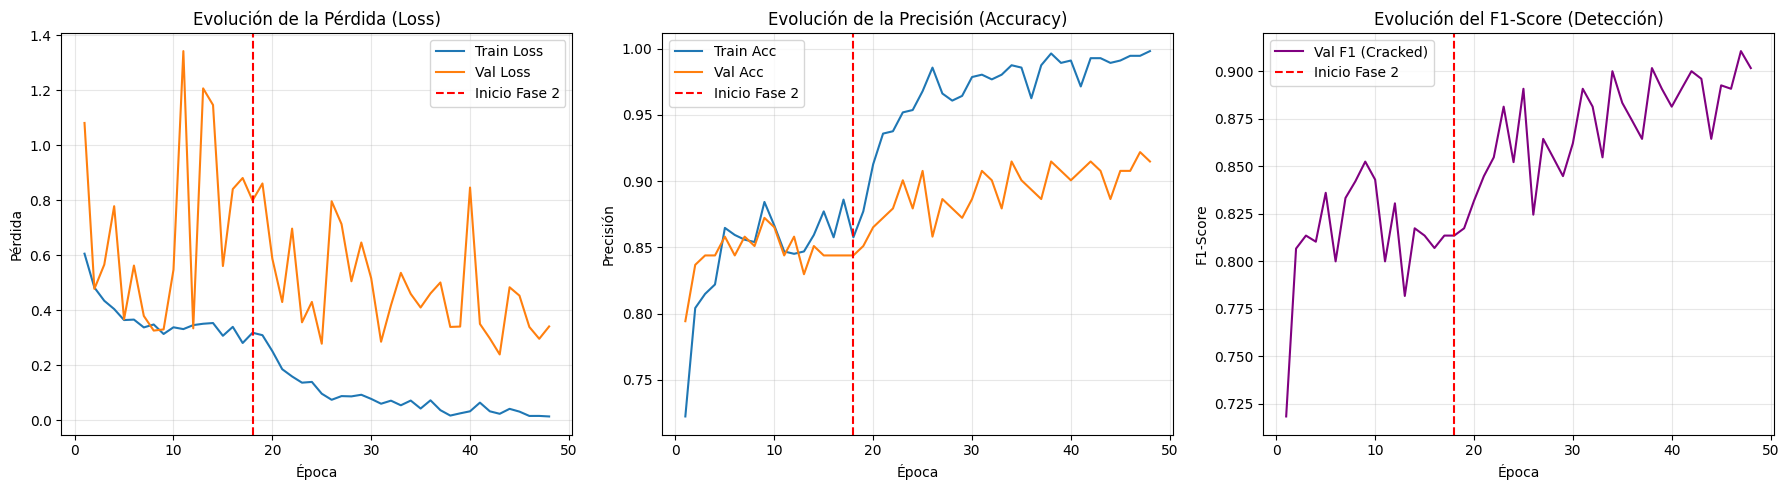

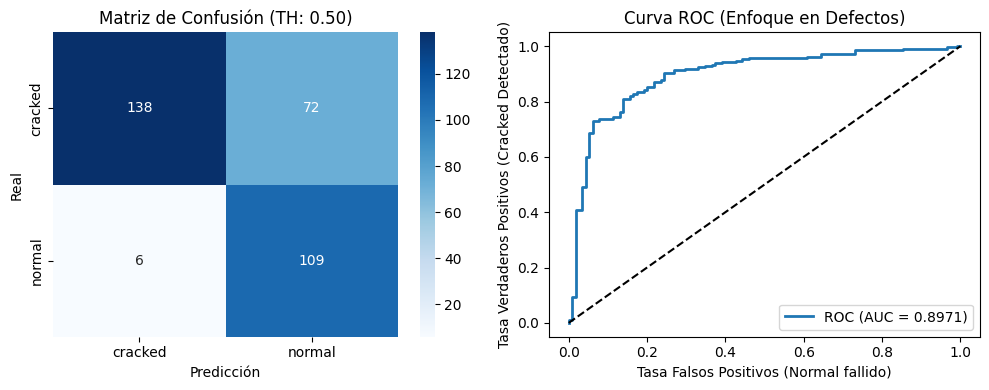

In [17]:
# -----------------------------
# 11. Gráficas (Curvas de Entrenamiento y ROC/CM)
# -----------------------------
y_true_cracked = (test_true == 0).astype(int)
auc = roc_auc_score(y_true_cracked, test_probs)
fpr, tpr, _ = roc_curve(y_true_cracked, test_probs)

test_precision_cracked = precision_score(test_true, test_pred_calibrado, pos_label=0, zero_division=0)
test_recall_cracked = recall_score(test_true, test_pred_calibrado, pos_label=0, zero_division=0)
test_f1_cracked = f1_score(test_true, test_pred_calibrado, pos_label=0, zero_division=0)

cm = confusion_matrix(test_true, test_pred_calibrado)

# --- Concatenación para la Gráfica Continua ---
train_loss_all = history['fase1']['train_loss'] + history['fase2']['train_loss']
val_loss_all = history['fase1']['val_loss'] + history['fase2']['val_loss']
train_acc_all = history['fase1']['train_acc'] + history['fase2']['train_acc']
val_acc_all = history['fase1']['val_acc'] + history['fase2']['val_acc']
val_f1_all = history['fase1']['val_f1_cracked'] + history['fase2']['val_f1_cracked']

fase1_epochs_run = len(history['fase1']['train_loss'])
epochs_total = range(1, len(train_loss_all) + 1)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs_total, train_loss_all, label='Train Loss')
plt.plot(epochs_total, val_loss_all, label='Val Loss')
if len(history['fase2']['train_loss']) > 0:
    plt.axvline(x=fase1_epochs_run, color='r', linestyle='--', label='Inicio Fase 2')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Época'); plt.ylabel('Pérdida')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epochs_total, train_acc_all, label='Train Acc')
plt.plot(epochs_total, val_acc_all, label='Val Acc')
if len(history['fase2']['train_loss']) > 0:
    plt.axvline(x=fase1_epochs_run, color='r', linestyle='--', label='Inicio Fase 2')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Época'); plt.ylabel('Precisión')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(epochs_total, val_f1_all, label='Val F1 (Cracked)', color='purple')
if len(history['fase2']['train_loss']) > 0:
    plt.axvline(x=fase1_epochs_run, color='r', linestyle='--', label='Inicio Fase 2')
plt.title('Evolución del F1-Score (Detección)')
plt.xlabel('Época'); plt.ylabel('F1-Score')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfica 2: Evaluación Final (ROC y Matriz de Confusión)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión (TH: {best_threshold:.2f})')
plt.ylabel('Real'); plt.xlabel('Predicción')

plt.subplot(1,2,2)
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa Falsos Positivos (Normal fallido)')
plt.ylabel('Tasa Verdaderos Positivos (Cracked Detectado)')
plt.title('Curva ROC (Enfoque en Defectos)')
plt.legend(); plt.tight_layout()
plt.show()

In [22]:
# -----------------------------
# 12. Checkpoint Documental y Exportación de Matrices
# -----------------------------
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_state_note": "Pesos correspondientes a la mejor época por val_f1_cracked antes de calibrar el umbral.",
    "model_name": XCEPTION_VARIANT,
    "best_threshold": best_threshold,
    "class_to_idx": full_train_dataset.class_to_idx,
    "use_custom_preprocess": USE_CUSTOM_PREPROCESS,
    "use_augmentation": USE_AUGMENTATION,
    "seed": SEED,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "lr_fase1": LEARNING_RATE_FASE1,
        "lr_fase2": LEARNING_RATE_FASE2,
        "epochs_fase1": EPOCHS_FASE1,
        "epochs_fase2": EPOCHS_FASE2,
        "patience": PATIENCE
    },
    "metrics_validation": {
        "best_val_f1_fase1": best_val_f1,
        "best_val_f1_fase2": best_val_f1_f2,
        "best_val_f1_calibrated": best_calibrated_f1
    },
    "metrics_test": {
        "test_auc": auc,
        "test_precision_cracked": test_precision_cracked,
        "test_recall_cracked": test_recall_cracked,
        "test_f1_cracked": test_f1_cracked
    },
    "history": history,
    "confusion_matrix": cm.tolist(),
    "classification_report": reporte_dict
}

torch.save(checkpoint, "xception_hybrid_final.pth")
print("\nModelo y metadatos de grado investigativo guardados exitosamente en 'xception_hybrid_final.pth'")


Modelo y metadatos de grado investigativo guardados exitosamente en 'xception_hybrid_final.pth'


Generando auditoría visual con mapas de calor...


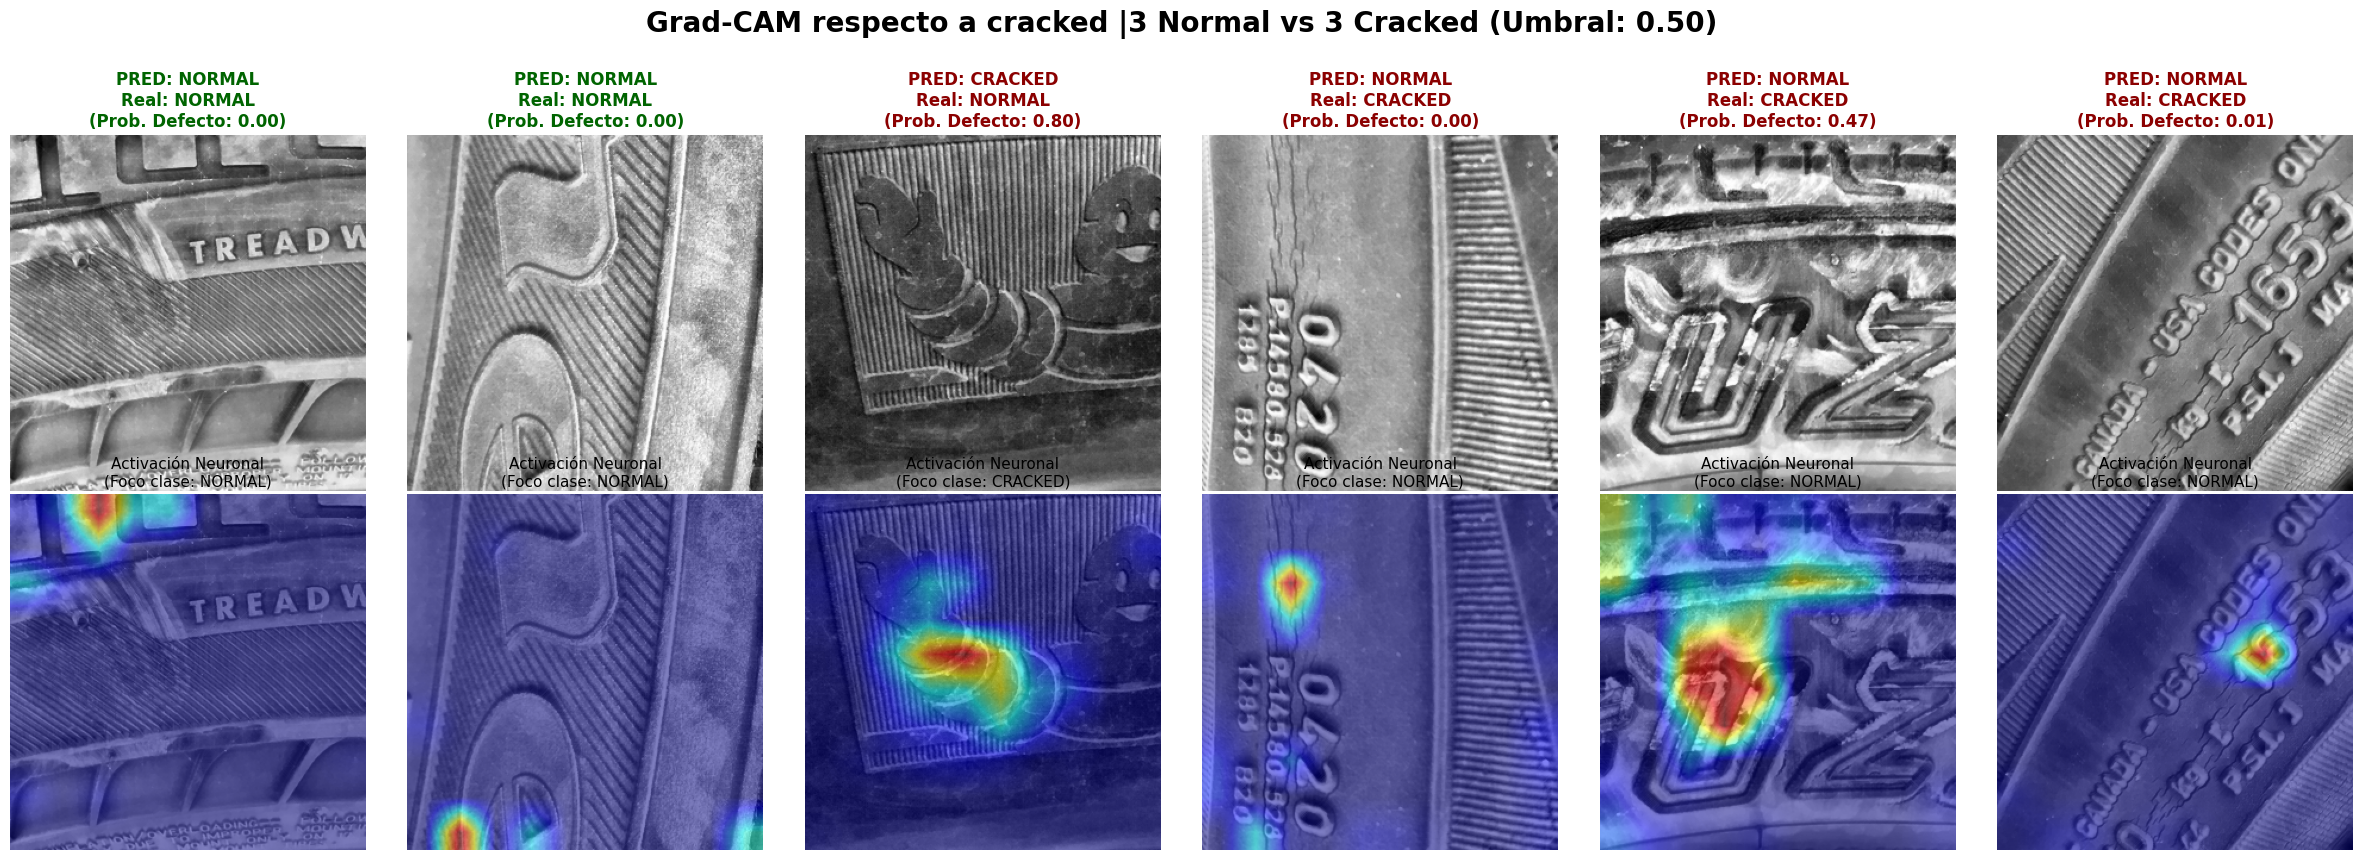


¡Script de Xception validado y finalizado!


In [37]:
# ==============================================================================
# AUDITORÍA VISUAL: 3 Predicciones Normales vs 3 Predicciones Cracked (Con Grad-CAM)
# ==============================================================================
if GRAD_CAM_AVAILABLE:
    print("Generando auditoría visual con mapas de calor...")

    idx_real_cracked = np.where(test_true == CRACKED_IDX)[0]
    idx_real_normal = np.where(test_true == NORMAL_IDX)[0]

    sample_cracked = random.sample(list(idx_real_cracked), min(3, len(idx_real_cracked)))
    sample_normal = random.sample(list(idx_real_normal), min(3, len(idx_real_normal)))
    muestras_totales = sample_normal + sample_cracked

    # 3. Inicializar Grad-CAM (Apuntando al último bloque convolucional)
    try:
        target_layers = [model.conv4]
    except AttributeError:
        target_layers = [model.blocks[-1]] # Variante para xception71.tf_in1k

    cam = GradCAM(model=model, target_layers=target_layers)

    # Transformación matemática de entrada
    tensor_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 4. Configurar Visualización (2 Filas: Imagen Original vs Grad-CAM, 6 Columnas)
    fig, axes = plt.subplots(2, 6, figsize=(24, 9))
    fig.suptitle(f'Grad-CAM respecto a cracked |3 Normal vs 3 Cracked (Umbral: {best_threshold:.2f})', fontsize=20, fontweight='bold')

    for i, idx in enumerate(muestras_totales):
        # A. Extraer imagen y etiquetas
        img_path, real_label = test_dataset.samples[idx]
        img_pil = Image.open(img_path).convert('RGB')

        pred_label = test_pred_calibrado[idx]
        prob_cracked = test_probs[idx]

        real_name = class_names[real_label].upper()
        pred_name = class_names[pred_label].upper()
        color_titulo = 'darkgreen' if real_label == pred_label else 'darkred'

        # B. Aplicar el pipeline físico (CLAHE + Black-Hat)
        img_resized = img_pil.resize((299, 299))
        img_preprocesada = preprocess_module(img_resized)

        # C. Tensor para el modelo
        input_tensor = tensor_transform(img_preprocesada).unsqueeze(0).to(DEVICE)
        img_float_np = np.float32(img_preprocesada) / 255.0

        # D. Generar mapa de calor
        targets = [ClassifierOutputTarget(CRACKED_IDX)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        cam_image = show_cam_on_image(img_float_np, grayscale_cam, use_rgb=True)

        # Fila 1: Imagen preprocesada (lo que ve la red)
        axes[0, i].imshow(img_preprocesada)
        texto_titulo = f"PRED: {pred_name}\nReal: {real_name}\n(Prob. Defecto: {prob_cracked:.2f})"
        axes[0, i].set_title(texto_titulo, color=color_titulo, fontsize=12, fontweight='bold')
        axes[0, i].axis('off')

        # Borde visual para separar Normales de Cracked
        if i == 2:
            axes[0, i].spines['right'].set_linewidth(3)
            axes[0, i].spines['right'].set_color('black')

        # Fila 2: Grad-CAM
        axes[1, i].imshow(cam_image)
        axes[1, i].set_title(f"Activación Neuronal\n(Foco clase: {pred_name})", fontsize=11)
        axes[1, i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('auditoria_predicciones.png', dpi=300)
    plt.show()

print("\n¡Script de Xception validado y finalizado!")